In [1]:
import pandas as pd
import numpy as np

def preprocess_data(dir: str, is_ml1m: bool) -> pd.DataFrame:
    """
    Preprocess the data, and set the number of users and items in the NeuMF config based on dataset size.

    Args:
        dir: The path to the ml32m dataset
    """
    if is_ml1m:
        dataset = pd.read_csv(dir, sep='::', header=None, names=['uid', 'mid', 'rating', 'timestamp'], engine='python')
    else:
        dataset = pd.read_csv(dir).rename(mapper={'userId': 'uid', 'itemId': 'mid'}, axis=1)
    user_id = dataset[['uid']].drop_duplicates().reindex()
    user_id['userId'] = np.arange(len(user_id))
    dataset = pd.merge(dataset, user_id, on=['uid'], how='left')
    item_id = dataset[['mid']].drop_duplicates()
    item_id['itemId'] = np.arange(len(item_id))
    dataset = pd.merge(dataset, item_id, on=['mid'], how='left')
    dataset = dataset[['userId', 'itemId', 'rating', 'timestamp']]
    print('Range of userId is [{}, {}]'.format(dataset.userId.min(), dataset.userId.max()))
    print('Range of itemId is [{}, {}]'.format(dataset.itemId.min(), dataset.itemId.max()))

    neumf_config['num_users'] = dataset.userId.max() + 1
    neumf_config['num_items'] = dataset.itemId.max() + 1

    return dataset

In [2]:
import sys
import os
import torch
import pennylane as qml
import matplotlib.pyplot as plt

# Ensure local imports work
if os.path.abspath('.') not in sys.path:
    sys.path.append(os.path.abspath('.'))

from NeuMF_QVC import QVCNeuMFEngine



# Define a configuration dict sufficient to initialize the model
neumf_config = {'alias': 'visualize',
                'num_epoch': 10,                    # original 100, less now because an epoch takes 40 min for implicit NeuMF
                'batch_size': 16,                    # original 256
                'optimizer': 'adam',                # original 'adam'
                'adam_lr': 1e-3,                    # original 0.001
                # 'sgd_lr': 0.003,                    # new for sgd
                # 'sgd_momentum': 0,                  # disable momentum for finetuning
                'num_users': None,                  # to be set after loading data
                'num_items': None,                  # to be set after loading data
                'latent_dim_mf': 8,                 # original 8
                'latent_dim_mlp': 8,                # original 8
                'num_negative': 4,                  # original 4
                'layers': [16, 64, 32, 16, 8],      # layers[0] is the concat of latent user vector & latent item vector, this is what they used in the og paper too
                'l2_regularization': 0,     # original 0
                'weight_init_gaussian': True,
                'use_cuda': True,
                'use_bachify_eval': True,
                'device_id': 0,
                'pretrain': False,
                'pretrain_neumf_dir': r"checkpoints\1_implicit_ml1m_Epoch99_HR0.6776_NDCG0.4098.model",
                'model_dir': 'checkpoints/{}_Epoch{}_HR{:.4f}_NDCG{:.4f}.model',
                'are_ratings_explicit': False,
                'n_qubits': 1,                      
                'q_depth': 2,                       # Number of variational layers
                'q_delta': 0.01,                     # Initial spread of random quantum weights
                'description': "Changed DQN to Gaussian DQN, kept Dense layer after DQN, used subset of 1000 users, set n_qubits to 1 for faster training and debugging"
                }

preprocess_data(dir=r"../data/ncf_preprocessed/ratings_subset.csv", is_ml1m=False)

# 1. Initialize the engine to see the full PyTorch architecture
engine = QVCNeuMFEngine(neumf_config)
print(engine.model)

Range of userId is [0, 999]
Range of itemId is [0, 13666]
Embedding(1000, 8)
Embedding(13667, 8)
Embedding(1000, 8)
Embedding(13667, 8)
Linear(in_features=16, out_features=64, bias=True)
Linear(in_features=64, out_features=32, bias=True)
Linear(in_features=32, out_features=16, bias=True)
Linear(in_features=16, out_features=8, bias=True)
Linear(in_features=16, out_features=8, bias=True)
Linear(in_features=16, out_features=1, bias=True)
Linear(in_features=8, out_features=1, bias=True)
Linear(in_features=1, out_features=16, bias=True)
Linear(in_features=16, out_features=8, bias=True)
QVCNeuMF(
  (embedding_user_mlp): Embedding(1000, 8)
  (embedding_item_mlp): Embedding(13667, 8)
  (embedding_user_mf): Embedding(1000, 8)
  (embedding_item_mf): Embedding(13667, 8)
  (fc_layers): ModuleList(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): Linear(in_feat

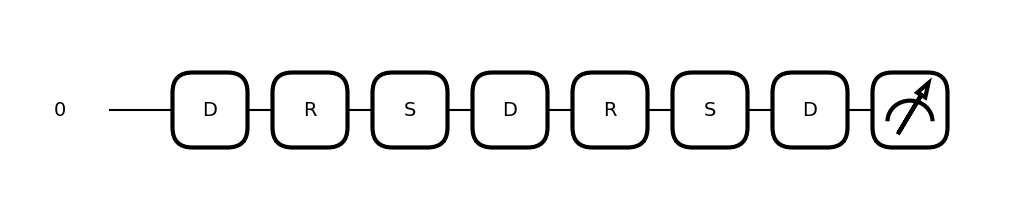

In [3]:
# 2. Visualize the internal continuous-variable quantum circuit
dummy_inputs = torch.randn(neumf_config['n_qubits'])
dummy_weights = engine.model.quantum_network.q_params

# Use PennyLane's matplotlib drawer
fig, ax = qml.draw_mpl(engine.model.quantum_network.quantum_nn)(dummy_inputs, dummy_weights)
plt.show()

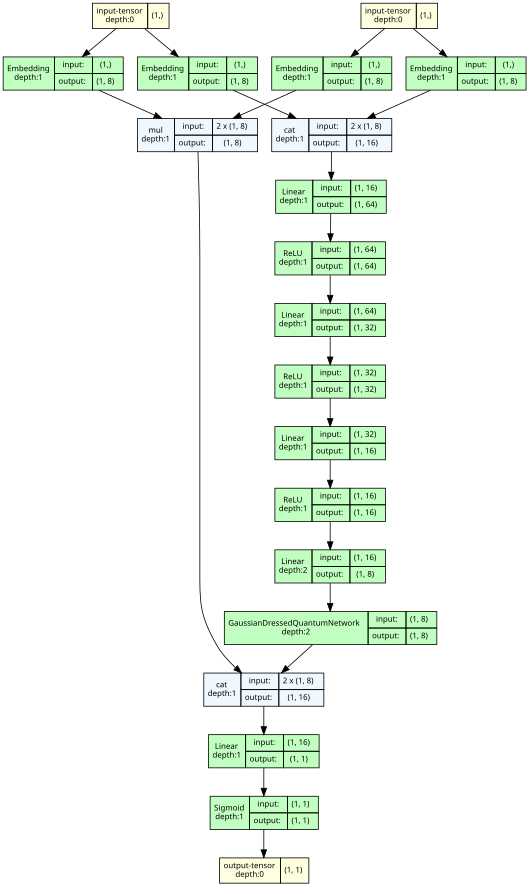

In [4]:
from torchview import draw_graph
import torch

dummy_user_indices = torch.tensor([0]).cuda()
dummy_item_indices = torch.tensor([0]).cuda()
# Do a forward pass and draw the high level architecture
# `depth` limits how nested the graph becomes. Increase it if you want to see inner layers.
model_graph = draw_graph(
    engine.model, 
    input_data=(dummy_user_indices, dummy_item_indices), 
    graph_name='QVCNeuMF',
    depth=2, 
    save_graph=True,
    filename='qvcneumf_architecture_torchview'
)

model_graph.visual_graph